# Volatility Modeling Challenges in Financial Time Series

Volatility is essential in derivatives pricing and risk management because it reflects market uncertainty and price fluctuations. Accurate estimates are necessary for proper pricing and effective hedging. However, challenges such as multicollinearity, overfitting, sensitivity to outliers, and skewness can distort results and reduce model reliability. If not addressed, these issues may lead to mispricing and poor financial decisions.


## 1. Multicollinearity

## Definition
$$X_j = \sum_{i \neq j} \alpha_i X_i + u$$

## Description
Multicollinearity occurs when explanatory variables in a regression model are highly correlated, making it difficult to estimate and interpret their individual effects on the dependent variable.

##Demonstration

In [ ]:
##Loading the dataset
import pandas as pd
df=pd.read_csv("financial_multicollinearity_dataset.csv")
df.head()

,Market,Sector,Stock,Bond,Index
0,0.052,0.049,0.061,0.020,0.050
1,0.031,0.030,0.042,0.018,0.032
2,0.065,0.061,0.078,0.025,0.063
3,0.028,0.027,0.039,0.017,0.029
4,0.047,0.044,0.059,0.019,0.046


In [ ]:
df.corr()
## The analysis shows very high correlations among the variables, indicating strong multicollinearity. This means the variables are closely related and may affect the reliability of regression results by making it difficult to separate their individual effects

,Market,Sector,Stock,Bond,Index
Market,1.000000,0.999722,0.998669,0.972136,0.998840
Sector,0.999722,1.000000,0.998715,0.973763,0.998568
Stock,0.998669,0.998715,1.000000,0.973203,0.998650
Bond,0.972136,0.973763,0.973203,1.000000,0.967246
Index,0.998840,0.998568,0.998650,0.967246,1.000000


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['Market','Sector','Bond','Index']]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif


,Variable,VIF
0,const,116.908664
1,Market,2237.277736
2,Sector,2078.652204
3,Bond,23.640758
4,Index,494.150660


The VIF results show very high values for most variables, indicating severe multicollinearity. This means the variables are highly correlated and may lead to unreliable regression results.

##Diagram

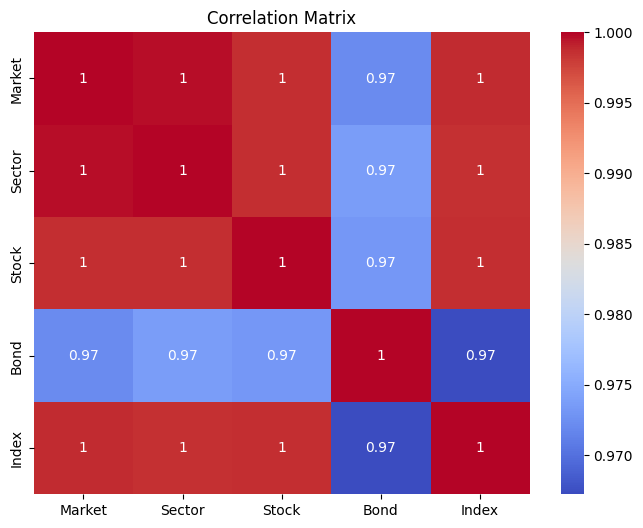

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

corr=df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## Diagnosis
Multicollinearity can be diagnosed by examining the correlation matrix and Variance Inflation Factor (VIF). In this study, very high correlation coefficients (close to 1) were observed between most variables, indicating strong linear relationships. Additionally, VIF values were extremely high (greater than 10), confirming severe multicollinearity among the explanatory variables.

##Damage caused by the problem
Multicollinearity makes regression results unreliable because it becomes difficult to separate the individual effect of each variable. It inflates standard errors, reduces the statistical significance of predictors, and can lead to misleading or unstable conclusions in the model.

##Directions: Suggested models that can address this
To handle multicollinearity, highly correlated variables can be removed or combined to reduce redundancy. Alternatively, Principal Component Analysis (PCA) can be used to convert correlated variables into independent components. Ridge Regression is also effective as it stabilizes the model by reducing the impact of large, unstable coefficients.


Multicollinearity leads to unstable and unreliable coefficient estimates, making it difficult to accurately measure risk factors. This can result in poor hedging decisions and incorrect identification of key market drivers.

##2. Overfitting
## Definition
$$
\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{f}(x_i))^2 \ll E[(Y - \hat{f}(X))^2]
$$

## Description
Overfitting occurs when a statistical or machine learning model learns the training data too well, including its noise and random fluctuations, instead of capturing the true underlying pattern. As a result, the model performs very well on the training data but poorly on new data because it fails to generalize.

##Demonstration

In [ ]:
## Loading the dataset

import pandas as pd
data = pd.read_csv("overfitting data.csv")
data.head()

,age,study_hours_per_week,attendance_rate,previous_grade,sleep_hours,final_grade
0,21,15,0.77,88,7.6,67.642182
1,24,25,0.74,78,8.0,61.681145
2,25,17,0.88,61,5.8,53.459216
3,21,20,0.88,85,7.4,67.329881
4,16,32,0.63,81,8.0,69.695778


In [ ]:
X = data.drop("final_grade", axis=1)
y = data["final_grade"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model1 = LinearRegression()
model1.fit(X_train, y_train)

train1 = mean_squared_error(y_train, model1.predict(X_train))
test1 = mean_squared_error(y_test, model1.predict(X_test))

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model2 = make_pipeline(PolynomialFeatures(5), LinearRegression())
model2.fit(X_train, y_train)

train2 = mean_squared_error(y_train, model2.predict(X_train))
test2 = mean_squared_error(y_test, model2.predict(X_test))

In [ ]:
print("Simple Model - Train:", train1)
print("Simple Model - Test:", test1)

print("Complex Model - Train:", train2)
print("Complex Model - Test:", test2)

Simple Model - Train: 16.300570543590837
Simple Model - Test: 16.034153515280067
Complex Model - Train: 3.1086911557299485e-18
Complex Model - Test: 4535.484535407452


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Simple Model", "Complex Model"],
    "Training Error": [train1, train2],
    "Test Error": [test1, test2]
})

results

,Model,Training Error,Test Error
0,Simple Model,1.630057e+01,16.034154
1,Complex Model,3.108691e-18,4535.484535


## Results

The simple model has similar training and test errors, indicating good performance.

The complex model has an extremely low training error but a very high test error.

This shows that the model fits the training data perfectly but fails to generalize to new data.

Therefore, overfitting is present.

##Diagram

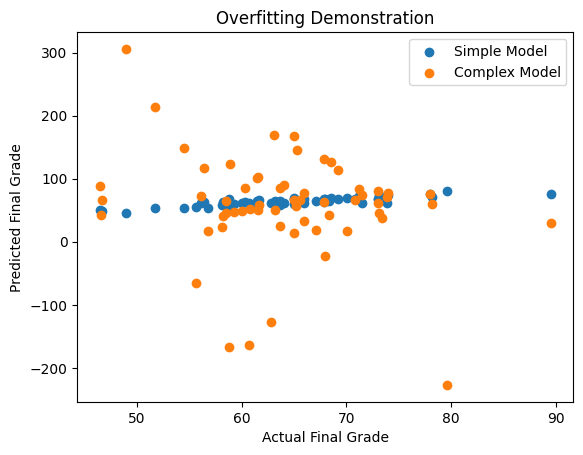

In [ ]:
import matplotlib.pyplot as plt

# Predictions
y_pred_simple = model1.predict(X_test)
y_pred_complex = model2.predict(X_test)

# Plot
plt.figure()

plt.scatter(y_test, y_pred_simple, label="Simple Model")
plt.scatter(y_test, y_pred_complex, label="Complex Model")

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Overfitting Demonstration")

plt.legend()
plt.show()

### Interpretation of diagram

The simple model predictions are closer to the actual values and show a consistent pattern.

The complex model predictions are widely scattered and include extreme values.

This indicates that the complex model does not generalize well to new data.

Therefore, the diagram confirms the presence of overfitting.

## Diagnosis of overfitting

Overfitting can be identified by comparing training and test errors.

If the training error is very low while the test error is very high, the model is overfitting.

In this case, the complex model has a near-zero training error and a very large test error.

The graphical analysis also shows widely scattered predictions.

Therefore, overfitting is present.

## Damage caused by overfitting

Overfitting causes the model to perform very well on training data but poorly on new (unseen) data.

This leads to:
- Poor prediction accuracy in real-world situations
- Unreliable and misleading results
- Inability of the model to generalize
- Wrong decisions based on inaccurate predictions


## Directions: Models to address overfitting

Overfitting can be reduced by using simpler or regularized models such as:

- Linear Regression  
- Ridge Regression  
- Lasso Regression  
- Random Forest


Overfitted models may perform well on historical data but fail in real market conditions. This can lead to underpricing or overpricing derivatives and result in significant financial losses.

##3. Sensitivity to outliers
##Definition

An estimator $T$ is said to be sensitive to outliers if its influence function is unbounded:

$$
IF(x; T, F) = \lim_{\epsilon \to 0} \frac{T(F_\epsilon) - T(F)}{\epsilon},
\quad \text{and} \quad \sup_x |IF(x;T,F)| = \infty.
$$

##Description
Sensitivity to outliers refers to how strongly extreme observations influence an estimator.
Highly sensitive estimators change significantly when outliers are present, which can distort results and lead to misleading conclusions.

In [ ]:
import pandas as pd
df = pd.read_csv("returns_outliers.csv")

df.head()
mean_with = df["Return"].mean()
mean_without = df["Return"][:-1].mean()

print("Mean with outlier:", round(mean_with,5))
print("Mean without outlier:", round(mean_without,5))

Mean with outlier: 0.00345
Mean without outlier: 0.00995


The mean return drops from 0.00995 to 0.00345 after including the outlier (-0.120).
This large change shows that the mean is highly sensitive to extreme values, confirming that it is not a robust estimator.

##Diagram

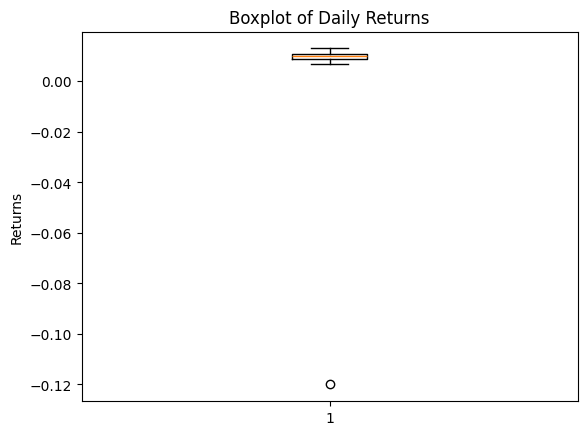

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Return"])
plt.title("Boxplot of Daily Returns")
plt.ylabel("Returns")
plt.show()

The boxplot appears compressed because the presence of a large negative outlier (-0.120) stretches the scale of the vertical axis.
As a result, the majority of the data points are tightly clustered, while the outlier is clearly separated, highlighting its extreme nature.

## Diagnosis

Sensitivity to outliers can be detected using graphical and statistical methods.
Boxplots can reveal extreme values that lie far from the rest of the data, while Z-scores can be used to identify observations with large deviations from the mean:

$$
Z = \frac{x - \mu}{\sigma}
$$

Observations with $|Z| > 3$ are typically considered outliers.

## Damage

Sensitivity to outliers distorts statistical estimates such as the mean and variance, leading to biased parameter estimates.
In volatility modeling, this can result in overstated or understated risk, causing poor pricing of derivatives and ineffective hedging decisions.

## Directions

To deal with outliers, we can use methods that are less affected by extreme values.
For example, using the median instead of the mean gives more stable results.
In volatility modeling, models like GARCH with heavy-tailed distributions (such as Student-t) can handle extreme values better.
We can also reduce the impact of outliers by trimming the data, winsorizing it, or using transformations like log returns.

##4. Skewness
##Definition
$$
\gamma_1 = \frac{E[(X - \mu)^3]}{\sigma^3}
$$

## Description

Skewness measures the asymmetry of a distribution around its mean.
A positive skew indicates a longer right tail, while a negative skew indicates a longer left tail.

##Demonstration


In [ ]:
import pandas as pd
from scipy.stats import skew

df = pd.read_csv("skewed_income_data.csv")

sk = skew(df["Income_USD"])

print("Skewness:", round(sk,4))

Skewness: 4.95


The computed skewness is 4.95, which is positive and relatively large.
This indicates that the distribution is highly positively skewed, with most income values clustered at lower levels and a few extremely high values stretching the distribution to the right.

##Diagram

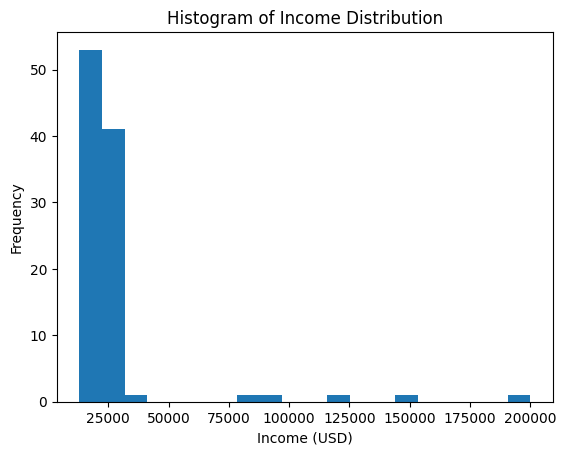

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Income_USD"], bins=20)
plt.title("Histogram of Income Distribution")
plt.xlabel("Income (USD)")
plt.ylabel("Frequency")
plt.show()



The histogram shows that most income values are concentrated at lower levels, while a few very high incomes extend far to the right.
This creates a long right tail, confirming that the distribution is positively skewed.

## Diagnosis

Skewness can be detected using both graphical and statistical methods.
A histogram can reveal asymmetry in the distribution, while the skewness coefficient is used as a formal measure:

$$
\gamma_1 = \frac{E[(X - \mu)^3]}{\sigma^3}
$$

A value of $\gamma_1 > 0$ indicates positive skewness, while $\gamma_1 < 0$ indicates negative skewness.

## Damage

Skewness can distort statistical analysis by making the mean and standard deviation misleading measures of central tendency and variability.
In financial modeling, this can lead to incorrect risk assessment and poor decision-making, especially when extreme values are present.

## Directions

Skewness can be handled by transforming the data, for example using logarithms to reduce asymmetry.
Models that allow for skewed distributions, such as skewed-normal or skewed-t models, can also be used.
In addition, robust methods that rely less on the mean, such as the median, can help reduce the impact of skewness.


Skewness affects the distribution of returns and tail risk, which are critical in derivatives pricing. Ignoring skewness can result in mispricing options and underestimating the likelihood of extreme market events.

##Reflection on Sensitivity to Outliers

Sensitivity to outliers was identified as a key challenge in volatility modeling because extreme values can distort statistical estimates such as the mean and variance.
In this notebook, the problem was demonstrated using a dataset of returns where a single extreme value significantly changed the mean.

To address this issue, robust methods such as the use of median and GARCH models with heavy-tailed distributions were suggested.
These approaches reduce the influence of extreme values and provide more reliable estimates in financial modeling.

This demonstrates that properly handling outliers improves the accuracy of volatility estimates and leads to better risk management decisions.

### References

- Wooldridge, J. M. (2013). *Introductory Econometrics: A Modern Approach*.
- Tsay, R. S. (2010). *Analysis of Financial Time Series*.

## Conclusion

Volatility modeling is essential for derivatives pricing and risk management, but it is affected by challenges such as multicollinearity, overfitting, sensitivity to outliers, and skewness. These issues can distort results and reduce model reliability. Addressing them is necessary to ensure accurate pricing, effective hedging, and better financial decision-making.
